# Phase 5: Would This Work on a Real Headset?

Everything so far used a 64-electrode research cap and a full recording session. A real assistive device (a wheelchair, a prosthetic) would have to work with **fewer electrodes** and **less setup time**. Phase 5 asks two practical questions, using the same data and the same decoder as before:

- **Experiment A:** how few electrodes can we keep before accuracy falls apart?
- **Experiment B:** how many calibration trials does a new user need before the decoder becomes usable?

We also open the black box: scalp maps show *where* on the head the decoder is looking.

![Phase 5 experiments](../images/phase5_experiments.png)

**The honest rule:** every accuracy is a cross-validated test result, and CSP is always fit on training trials only.

## Step 1: Load the Data

This notebook is self-contained, so we reload the imagined-fist trials for subjects 1–10 (the same ten as Phase 2). The recipe is the same as before: an 8–30 Hz bandpass, then trials cut from 0.5 to 4.0 s after each cue. This time we also attach the **electrode positions** to the data, so we can draw head maps.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from mne.channels import make_standard_montage
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

mne.set_log_level("ERROR")
warnings.filterwarnings("ignore")

In [2]:
RUNS = [4, 8, 12]        # runs where the person imagines closing the left or right fist

def load_epochs(subject, tmin=0.5, tmax=4.0):
    """Load one subject's imagined-fist trials as filtered epochs (8-30 Hz), with electrode positions attached."""
    paths = eegbci.load_data(subject, RUNS, verbose=False)
    raw = concatenate_raws([read_raw_edf(p, preload=True, verbose=False) for p in paths])
    eegbci.standardize(raw)                                              # fix the odd PhysioNet channel names
    raw.set_montage(make_standard_montage("standard_1005"), on_missing="ignore")
    raw.filter(8.0, 30.0, fir_design="firwin", verbose=False)
    events, _ = mne.events_from_annotations(raw, event_id=dict(T1=2, T2=3), verbose=False)
    return mne.Epochs(raw, events, dict(left=2, right=3), tmin=tmin, tmax=tmax,
                      baseline=None, picks="eeg", preload=True, verbose=False)

def cv_accuracy(X, y, n_repeats=5, seed=0):
    """Cross-validated accuracy of CSP + LDA (CSP is re-fit inside every fold, so there is no leakage)."""
    pipe = Pipeline([("csp", CSP(n_components=min(4, X.shape[1]), log=True, norm_trace=False)),
                     ("lda", LinearDiscriminantAnalysis())])
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats, random_state=seed)
    return cross_val_score(pipe, X, y, cv=cv).mean()

In [3]:
subjects = list(range(1, 11))
data = {}
for s in subjects:
    data[s] = load_epochs(s)
    print(f"subject {s}: {len(data[s])} trials, {len(data[s].ch_names)} channels")

# sanity check against Phase 2
ep = data[1]
acc = cv_accuracy(ep.get_data(), ep.events[:, 2])
print(f"\nSubject 1, all {len(ep.ch_names)} channels: {acc:.1%}   (Phase 2 reported 71.8%)")

subject 1: 45 trials, 64 channels
subject 2: 45 trials, 64 channels
subject 3: 45 trials, 64 channels
subject 4: 45 trials, 64 channels
subject 5: 45 trials, 64 channels
subject 6: 45 trials, 64 channels
subject 7: 45 trials, 64 channels
subject 8: 45 trials, 64 channels
subject 9: 45 trials, 64 channels
subject 10: 45 trials, 64 channels

Subject 1, all 64 channels: 70.7%   (Phase 2 reported 71.8%)


## Step 2: Which Electrodes Would a Headset Keep?

Motor imagery shows up over the **motor cortex**, a strip across the top of the head. The most useful electrodes sit right above it:

- **C3** (left side) and **C4** (right side): above the hand areas. Remember the crossed wiring: imagining the right fist changes C3, and the left fist changes C4.
- **Cz** (middle): above the foot area.

We keep four nested sets, each containing the one before it: **3** electrodes (C3, Cz, C4), **8**, **16**, and **21** (the whole motor strip, three rows of seven). The full cap has 64. Consumer headsets typically have somewhere between 4 and 16 electrodes, so the 3, 8 and 16 sets are the realistic ones.

In [4]:
SUBSETS = {3: ["C3", "Cz", "C4"],
           8: ["C3", "Cz", "C4", "FC3", "FC4", "CP3", "CP4", "CPz"]}
SUBSETS[16] = SUBSETS[8] + ["C1", "C2", "C5", "C6", "FC1", "FC2", "CP1", "CP2"]
SUBSETS[21] = SUBSETS[16] + ["FC5", "FC6", "FCz", "CP5", "CP6"]     # the whole motor strip (3 rows of 7)

ep1 = data[subjects[0]]
missing = [c for k in SUBSETS for c in SUBSETS[k] if c not in ep1.ch_names]
print("channels missing:", missing)                                  # should be an empty list
print({k: len(v) for k, v in SUBSETS.items()}, "+ all", len(ep1.ch_names))

channels missing: []
{3: 3, 8: 8, 16: 16, 21: 21} + all 64


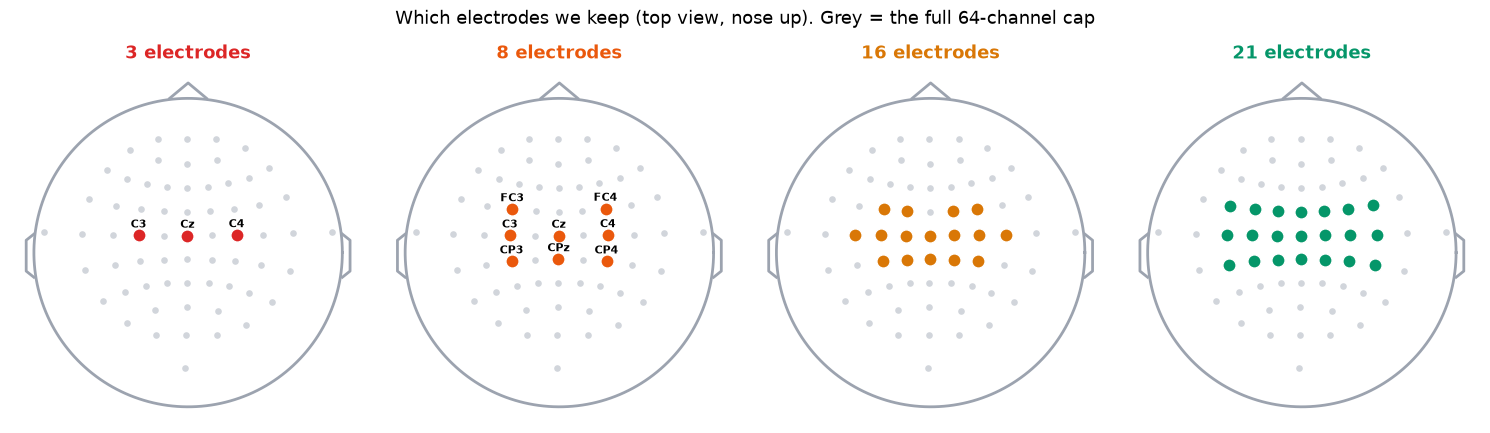

In [5]:
pos3d = ep1.get_montage().get_positions()["ch_pos"]
names_all = ep1.ch_names

def head_xy(name):
    """Top-down view of the scalp (nose up): angle from the top of the head becomes distance from the center."""
    x, y, z = pos3d[name] / np.linalg.norm(pos3d[name])
    theta, phi = np.arccos(z), np.arctan2(y, x)
    return theta * np.cos(phi), theta * np.sin(phi)

xy = np.array([head_xy(n) for n in names_all])
R = np.linalg.norm(xy, axis=1).max() * 1.06
colors = {3: "#dc2626", 8: "#ea580c", 16: "#d97706", 21: "#059669"}

fig, axes = plt.subplots(1, 4, figsize=(15, 4.2))
for ax, k in zip(axes, [3, 8, 16, 21]):
    t = np.linspace(0, 2 * np.pi, 200)
    ax.plot(R * np.cos(t), R * np.sin(t), color="#9ca3af", lw=2)                         # head
    ax.plot([-0.12 * R, 0, 0.12 * R], [R, 1.1 * R, R], color="#9ca3af", lw=2)            # nose
    for sx in (-1, 1):
        ax.plot(sx * R * np.array([1.0, 1.05, 1.05, 1.0]), R * np.array([0.12, 0.08, -0.12, -0.16]), color="#9ca3af", lw=2)  # ears
    ax.scatter(xy[:, 0], xy[:, 1], s=14, color="#d1d5db", zorder=2)                      # every electrode, faint
    sel = [names_all.index(c) for c in SUBSETS[k]]
    ax.scatter(xy[sel, 0], xy[sel, 1], s=90, color=colors[k], edgecolor="white", zorder=3)
    if k <= 8:
        for i in sel:
            ax.text(xy[i, 0], xy[i, 1] + 0.09, names_all[i], ha="center", fontsize=8, fontweight="bold")
    ax.set_title(f"{k} electrodes", fontsize=13, fontweight="bold", color=colors[k])
    ax.set_aspect("equal"); ax.axis("off")
fig.suptitle("Which electrodes we keep (top view, nose up). Grey = the full 64-channel cap", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../images/electrode_subsets.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 3: Where Does CSP Look?

CSP finds weighted mixes of the electrodes that separate left-fist trials from right-fist trials. Each mix has two faces:

- the **filter** w, the recipe: "multiply each channel by its weight and add them up";
- the **pattern** a, the *footprint* of that source on the scalp: a = Σw / (wᵀΣw), where Σ is the covariance matrix of the channels (how they move together).

Plotting the pattern as a head map shows where the decoded activity lives. In the textbook picture, the two patterns light up opposite sides of the motor cortex (near C3 and C4), because each imagined fist suppresses the rhythm on the opposite side. Red and blue are only the sign of the weight, and the sign of a CSP pattern is arbitrary, so what matters is **where the strong colors sit**.

We show a strong decoder (subject 7), a middle one (subject 2) and a weak one (subject 5). We'll check whether the maps match the textbook picture, and whether the weak subject's map looks different.

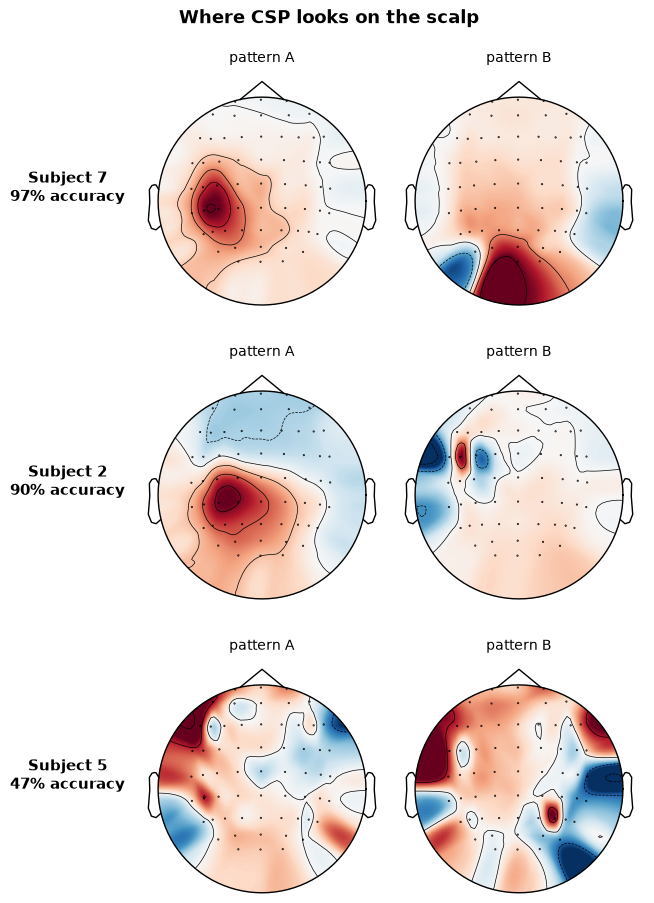

In [6]:
LOW_EDGE = ("T9", "T10", "Iz")           # the three lowest electrodes sit below the head outline, so we leave them out of the maps

def csp_patterns(epochs):
    """Fit CSP on all of a subject's trials (for display only) and return its two most extreme patterns."""
    csp = CSP(n_components=4, log=True, norm_trace=False, component_order="alternate")
    csp.fit(epochs.get_data(), epochs.events[:, 2])
    pats = csp.patterns_[:2].copy()
    for p in pats:                                       # an eigenvector's sign is arbitrary: make the strongest weight positive
        if p[np.argmax(np.abs(p))] < 0: p *= -1
    return pats

show_subjects = [7, 2, 5]          # a strong decoder, a middle one, and a weak one
fig, axes = plt.subplots(len(show_subjects), 2, figsize=(6.6, 3.1 * len(show_subjects)))
for r, s in enumerate(show_subjects):
    ep = data[s]
    acc = cv_accuracy(ep.get_data(), ep.events[:, 2])
    keep = [i for i, n in enumerate(ep.ch_names) if n not in LOW_EDGE]
    info_k = mne.pick_info(ep.info, keep)
    pats = csp_patterns(ep)[:, keep]
    for c in range(2):
        v = np.abs(pats[c]).max()
        mne.viz.plot_topomap(pats[c], info_k, axes=axes[r, c], show=False, cmap="RdBu_r", vlim=(-v, v),
                             contours=4, sphere=0.105, extrapolate="head")
        axes[r, c].set_title("pattern A" if c == 0 else "pattern B", fontsize=10)
    axes[r, 0].set_ylabel(f"Subject {s}\n{acc:.0%} accuracy", fontsize=11, fontweight="bold", rotation=0, labelpad=50, va="center")
fig.suptitle("Where CSP looks on the scalp", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/csp_scalp_maps.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4: How Few Electrodes Do We Need?

For every subject we re-run the same decoder (CSP + LDA, 5-fold cross-validation repeated 5 times) with fewer electrodes:

- **Motor strip (our choice):** the nested sets from Step 2, with 21, 16, 8 and 3 electrodes.
- **Random electrodes (the control):** the same *number* of electrodes, picked at random and averaged over 10 draws.

The control separates two things that are easy to confuse: *having fewer electrodes* and *having well-placed electrodes*. If the motor strip beats random picks, the neuroscience is doing real work, not just the electrode count.

Accuracy could fall as electrodes disappear, stay flat, or even rise, since fewer noisy channels can mean less overfitting. We report whatever happens.

In [7]:
import os, time
os.environ["MNE_LOGGING_LEVEL"] = "ERROR"          # keep the parallel workers quiet too

def cv_accuracy(X, y, n_repeats=5, seed=0, n_jobs=-1):
    """Same as before, but the cross-validation folds run in parallel (set n_jobs=1 if this causes trouble)."""
    pipe = Pipeline([("csp", CSP(n_components=min(4, X.shape[1]), log=True, norm_trace=False)),
                     ("lda", LinearDiscriminantAnalysis())])
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats, random_state=seed)
    return cross_val_score(pipe, X, y, cv=cv, n_jobs=n_jobs).mean()

ks = [3, 8, 16, 21]
n_random = 10                       # random electrode sets averaged per size
rng = np.random.default_rng(0)
acc_all, acc_motor, acc_rand = {}, {}, {}

t0 = time.time()
for s in subjects:
    ep = data[s]
    X, y, names = ep.get_data(), ep.events[:, 2], ep.ch_names
    acc_all[s] = cv_accuracy(X, y)
    acc_motor[s] = {k: cv_accuracy(X[:, [names.index(c) for c in SUBSETS[k]], :], y) for k in ks}
    acc_rand[s] = {k: np.mean([cv_accuracy(X[:, rng.choice(len(names), k, replace=False), :], y)
                               for _ in range(n_random)]) for k in ks}
    print(f"subject {s:2d}: all 64 = {acc_all[s]:.0%} | motor strip 21/16/8/3 = "
          + " / ".join(f"{acc_motor[s][k]:.0%}" for k in (21, 16, 8, 3)) + f"   ({time.time() - t0:.0f} s)")

subject  1: all 64 = 71% | motor strip 21/16/8/3 = 75% / 76% / 66% / 69%   (10 s)
subject  2: all 64 = 90% | motor strip 21/16/8/3 = 93% / 91% / 90% / 63%   (17 s)
subject  3: all 64 = 50% | motor strip 21/16/8/3 = 44% / 51% / 52% / 40%   (23 s)
subject  4: all 64 = 50% | motor strip 21/16/8/3 = 62% / 71% / 70% / 78%   (30 s)
subject  5: all 64 = 47% | motor strip 21/16/8/3 = 54% / 40% / 42% / 43%   (37 s)
subject  6: all 64 = 48% | motor strip 21/16/8/3 = 48% / 48% / 43% / 40%   (44 s)
subject  7: all 64 = 97% | motor strip 21/16/8/3 = 98% / 97% / 98% / 87%   (51 s)
subject  8: all 64 = 44% | motor strip 21/16/8/3 = 43% / 48% / 55% / 53%   (58 s)
subject  9: all 64 = 38% | motor strip 21/16/8/3 = 45% / 36% / 48% / 42%   (65 s)
subject 10: all 64 = 48% | motor strip 21/16/8/3 = 60% / 63% / 63% / 72%   (72 s)


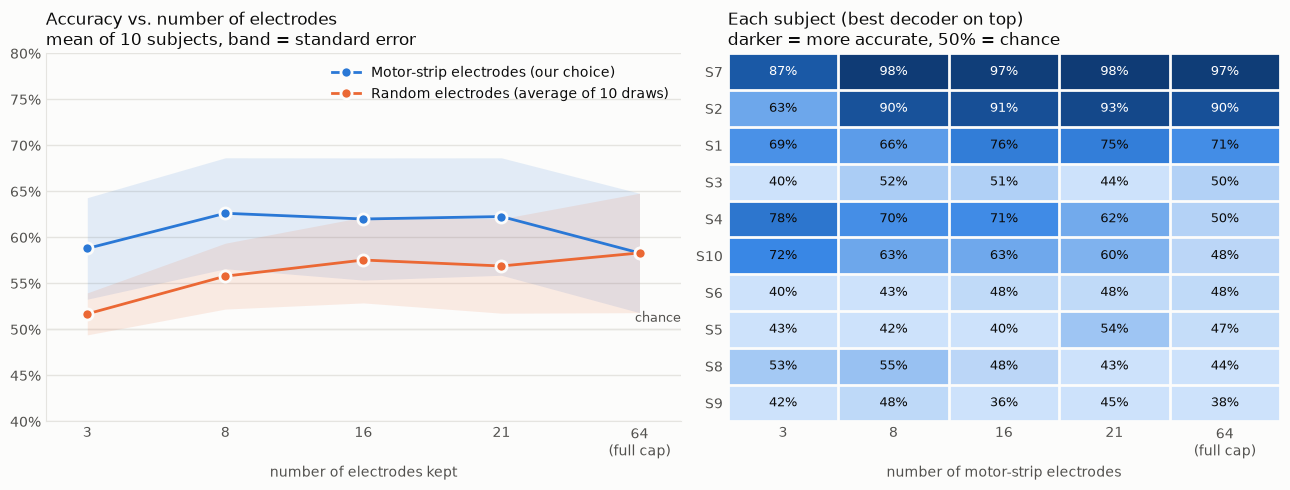

In [8]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"

xs = np.arange(5)                                           # 3, 8, 16, 21 electrodes, then the full cap
xlabels = ["3", "8", "16", "21", "64\n(full cap)"]
M  = np.array([[acc_motor[s][k] for k in ks] + [acc_all[s]] for s in subjects])      # subjects x 5
Rn = np.array([[acc_rand[s][k]  for k in ks] + [acc_all[s]] for s in subjects])
sem = lambda a: a.std(axis=0, ddof=1) / np.sqrt(len(a))

fig, (ax, hm) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.15, 1]}, facecolor=SURFACE)

# left: mean accuracy vs number of electrodes
ax.set_facecolor(SURFACE)
ax.axhline(0.5, color=GRID, lw=1, zorder=1)
ax.text(4.3, 0.505, "chance", ha="right", va="bottom", fontsize=9, color=INK2)
for arr, color, label in [(M, BLUE, "Motor-strip electrodes (our choice)"),
                          (Rn, ORANGE, f"Random electrodes (average of {n_random} draws)")]:
    m, e = arr.mean(axis=0), sem(arr)
    ax.fill_between(xs, m - e, m + e, color=color, alpha=0.12, lw=0)
    ax.plot(xs, m, color=color, lw=2, marker="o", ms=8, mec=SURFACE, mew=2, label=label, zorder=3)
top = max(0.8, np.ceil((max(M.mean(0).max(), Rn.mean(0).max()) + 0.05) * 10) / 10)
ax.set_ylim(0.4, top); ax.set_xlim(-0.3, 4.3)
ax.set_xticks(xs, xlabels)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.grid(axis="y", color=GRID, lw=1); ax.set_axisbelow(True)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for sp in ("left", "bottom"): ax.spines[sp].set_color(GRID)
ax.tick_params(colors=INK2, length=0)
ax.set_xlabel("number of electrodes kept", color=INK2)
ax.set_title(f"Accuracy vs. number of electrodes\nmean of {len(subjects)} subjects, band = standard error", loc="left", fontsize=12, color=INK)
ax.legend(frameon=False, loc="best", labelcolor=INK)

# right: every subject, motor-strip electrodes only
hm.set_facecolor(SURFACE)
order = np.argsort(-M[:, -1])                               # best subject on top
cmap = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
hm.imshow(M[order], cmap=cmap, vmin=0.45, vmax=1.0, aspect="auto")
for i in range(len(order)):
    for j in range(5):
        v = M[order][i, j]
        hm.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9, color="white" if v > 0.78 else INK)
hm.set_xticks(xs, xlabels)
hm.set_yticks(range(len(order)), [f"S{subjects[i]}" for i in order])
hm.set_xticks(np.arange(-0.5, 5, 1), minor=True); hm.set_yticks(np.arange(-0.5, len(order), 1), minor=True)
hm.grid(which="minor", color=SURFACE, lw=2); hm.tick_params(which="both", length=0, colors=INK2)
for sp in hm.spines.values(): sp.set_visible(False)
hm.set_xlabel("number of motor-strip electrodes", color=INK2)
hm.set_title("Each subject (best decoder on top)\ndarker = more accurate, 50% = chance", loc="left", fontsize=12, color=INK)

plt.tight_layout()
plt.savefig("../images/electrode_count_accuracy.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()

In [9]:
print("Mean accuracy across subjects")
for j, lab in enumerate(["3", "8", "16", "21", "64"]):
    print(f"  {lab:>2} electrodes:  motor strip {M[:, j].mean():.1%}   random {Rn[:, j].mean():.1%}")
d = M[:, 3] - M[:, 4]
print(f"\n21 motor-strip electrodes vs. the full cap: mean difference {d.mean():+.1%}, "
      f"as good or better in {(d >= 0).sum()} of {len(d)} subjects")
if 7 in acc_all:
    print("Subject 7:  64 ch %.0f%%,  21 ch %.0f%%,  8 ch %.0f%%,  3 ch %.0f%%" % (
        100 * acc_all[7], 100 * acc_motor[7][21], 100 * acc_motor[7][8], 100 * acc_motor[7][3]))

Mean accuracy across subjects
   3 electrodes:  motor strip 58.8%   random 51.7%
   8 electrodes:  motor strip 62.6%   random 55.8%
  16 electrodes:  motor strip 62.0%   random 57.5%
  21 electrodes:  motor strip 62.3%   random 56.9%
  64 electrodes:  motor strip 58.3%   random 58.3%

21 motor-strip electrodes vs. the full cap: mean difference +4.0%, as good or better in 8 of 10 subjects
Subject 7:  64 ch 97%,  21 ch 98%,  8 ch 98%,  3 ch 87%


## Reading the Result (Electrode Count)

| | 3 electrodes | 8 | 16 | 21 | 64 (full cap) |
|---|---|---|---|---|---|
| **Motor strip** (mean accuracy, 10 subjects) | 58.8% | 62.6% | 62.0% | 62.3% | 58.3% |
| **Random electrodes** (mean of 10 draws) | 51.7% | 55.8% | 57.5% | 56.9% | 58.3% |

**What we learned**
- **Where the electrodes sit matters.** At every size, the motor strip beats random electrodes by about 4 to 7 points. Three random electrodes sit at chance.
- **Eight motor-strip electrodes are a sweet spot for the strong subjects.** Subject 7 scores 98% (full cap: 97%) and subject 2 scores 90% (full cap: 90%). Dropping to 3 electrodes costs them 10 and 27 points.
- **Subject 7's second CSP pattern sat at the back of the head, but it wasn't needed.** The motor strip alone matches the full cap, so the decoding comes from the motor area.
- **For weak subjects, fewer electrodes often helped.** Subjects 4 and 10 jump from about 50% with the full cap to 60–78% with motor-strip electrodes. A plausible reason is overfitting: with about 36 training trials and 64 channels, CSP can fit noise. We did not test this explanation directly.

**What we cannot claim**
- Each subject has only 45 trials, so one subject's accuracy carries roughly ±7 points of noise, and the shaded bands in the chart overlap.
- Subjects 3, 5, 6, 8 and 9 stay near chance at every electrode count. With a simple decoder and 45 trials, we cannot say whether their signal is absent or the decoder is too weak.
- The motor-strip sets were chosen from anatomy before seeing any results, so the +4.0 point mean gain at 21 electrodes is not cherry-picked. But most of it comes from the weak subjects moving up from chance.

## Step 5: How Many Calibration Trials Does a New User Need?

A real headset can't ask a new user for 45 trials before it works. So we ask: **how accurate is the decoder after only n training trials?**

For each subject we repeat 30 times:
1. Randomly hold out **15 trials** as a fresh test set. These are never used for training.
2. Train on **n** of the remaining trials (n = 6, 12, 18, 24, 30), with CSP fit only on those n trials.
3. Measure accuracy on the held-out 15.

We do this twice: with the realistic **8 motor-strip electrodes** and with the **full 64-electrode cap**. One trial takes about 8 seconds (4 s of imagery plus a rest), so 30 trials is roughly 4 minutes of recording. That excludes putting the headset on and any rest breaks.

In [10]:
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

sizes = [6, 12, 18, 24, 30]         # number of training trials
n_test, n_splits = 15, 30

def one_split(X, y, pool, test, seed):
    """Train on the first n trials drawn from the pool (class-balanced), test on the held-out trials."""
    r = np.random.default_rng(seed)
    accs = []
    for n in sizes:
        if n >= len(pool):
            tr = pool
        else:
            tr, _ = train_test_split(pool, train_size=n, stratify=y[pool], random_state=int(r.integers(1_000_000_000)))
        pipe = Pipeline([("csp", CSP(n_components=min(4, X.shape[1]), log=True, norm_trace=False)),
                         ("lda", LinearDiscriminantAnalysis())])
        pipe.fit(X[tr], y[tr])
        accs.append(pipe.score(X[test], y[test]))
    return accs

def learning_curve(X, y, seed=0):
    sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=n_test, random_state=seed)
    rows = Parallel(n_jobs=-1)(delayed(one_split)(X, y, pool, test, seed * 1000 + i)
                               for i, (pool, test) in enumerate(sss.split(X, y)))
    return np.array(rows).mean(axis=0)                      # mean accuracy at each training size

curve8, curve64 = {}, {}
t0 = time.time()
for s in subjects:
    ep = data[s]
    X, y, names = ep.get_data(), ep.events[:, 2], ep.ch_names
    idx8 = [names.index(c) for c in SUBSETS[8]]
    curve8[s] = learning_curve(X[:, idx8, :], y)
    curve64[s] = learning_curve(X, y)
    print(f"subject {s:2d}: 8 electrodes, after {sizes[0]}/{sizes[-1]} trials = {curve8[s][0]:.0%} / {curve8[s][-1]:.0%}"
          f" | 64 electrodes = {curve64[s][0]:.0%} / {curve64[s][-1]:.0%}   ({time.time() - t0:.0f} s)")

subject  1: 8 electrodes, after 6/30 trials = 59% / 70% | 64 electrodes = 55% / 69%   (2 s)
subject  2: 8 electrodes, after 6/30 trials = 73% / 90% | 64 electrodes = 59% / 89%   (3 s)
subject  3: 8 electrodes, after 6/30 trials = 48% / 52% | 64 electrodes = 54% / 57%   (5 s)
subject  4: 8 electrodes, after 6/30 trials = 56% / 70% | 64 electrodes = 49% / 54%   (7 s)
subject  5: 8 electrodes, after 6/30 trials = 46% / 50% | 64 electrodes = 47% / 50%   (8 s)
subject  6: 8 electrodes, after 6/30 trials = 48% / 46% | 64 electrodes = 53% / 50%   (10 s)
subject  7: 8 electrodes, after 6/30 trials = 78% / 96% | 64 electrodes = 72% / 98%   (11 s)
subject  8: 8 electrodes, after 6/30 trials = 49% / 51% | 64 electrodes = 49% / 44%   (12 s)
subject  9: 8 electrodes, after 6/30 trials = 48% / 48% | 64 electrodes = 52% / 42%   (13 s)
subject 10: 8 electrodes, after 6/30 trials = 55% / 62% | 64 electrodes = 50% / 49%   (14 s)


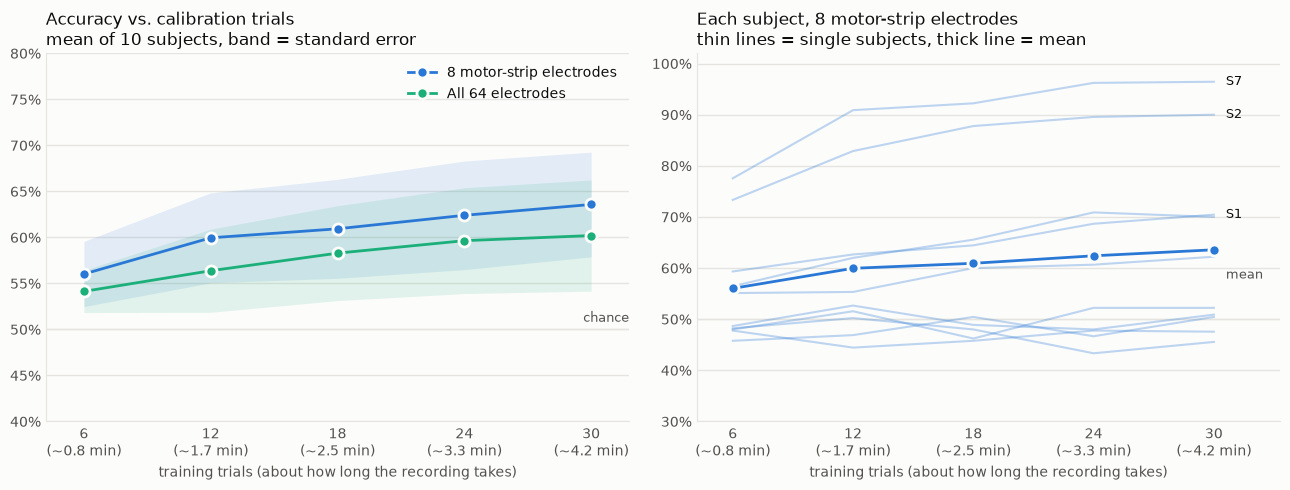

In [11]:
AQUA = "#1baf7a"
A8  = np.array([curve8[s]  for s in subjects])              # subjects x training sizes
A64 = np.array([curve64[s] for s in subjects])
xs = np.arange(len(sizes))
xl = [f"{n}\n(~{n * 8.3 / 60:.1f} min)" for n in sizes]     # one trial is about 8.3 s of recording

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5), facecolor=SURFACE)

def style(a):
    a.set_facecolor(SURFACE)
    a.grid(axis="y", color=GRID, lw=1); a.set_axisbelow(True)
    for sp in ("top", "right"): a.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): a.spines[sp].set_color(GRID)
    a.tick_params(colors=INK2, length=0)
    a.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    a.set_xticks(xs, xl)
    a.axhline(0.5, color=GRID, lw=1, zorder=1)
    a.set_xlabel("training trials (about how long the recording takes)", color=INK2)

# left: mean learning curve, two electrode setups
style(ax)
ax.text(xs[-1] + 0.3, 0.505, "chance", ha="right", va="bottom", fontsize=9, color=INK2)
for arr, color, label in [(A8, BLUE, "8 motor-strip electrodes"), (A64, AQUA, "All 64 electrodes")]:
    m, e = arr.mean(axis=0), sem(arr)
    ax.fill_between(xs, m - e, m + e, color=color, alpha=0.12, lw=0)
    ax.plot(xs, m, color=color, lw=2, marker="o", ms=8, mec=SURFACE, mew=2, label=label, zorder=3)
ax.set_xlim(-0.3, xs[-1] + 0.3)
ax.set_ylim(0.4, max(0.8, np.ceil((max(A8.mean(0).max(), A64.mean(0).max()) + 0.05) * 10) / 10))
ax.set_title(f"Accuracy vs. calibration trials\nmean of {len(subjects)} subjects, band = standard error", loc="left", fontsize=12, color=INK)
ax.legend(frameon=False, loc="best", labelcolor=INK)

# right: each subject on its own (8 electrodes)
style(ax2)
for row in A8:
    ax2.plot(xs, row, color=BLUE, lw=1.5, alpha=0.3)
ax2.plot(xs, A8.mean(axis=0), color=BLUE, lw=2, marker="o", ms=8, mec=SURFACE, mew=2, zorder=3)
ends = sorted([(A8[i, -1], subjects[i]) for i in np.argsort(-A8[:, -1])[:3]], reverse=True)   # label only the top three
ylab = []
for v, s in ends:                                            # nudge labels apart so they never overlap
    y_ = v if not ylab else min(v, ylab[-1] - 0.035)
    ylab.append(y_)
    ax2.text(xs[-1] + 0.1, y_, f"S{s}", va="center", fontsize=9, color=INK)
ax2.text(xs[-1] + 0.1, A8.mean(axis=0)[-1] - 0.05, "mean", va="center", fontsize=9, color=INK2)
ax2.set_xlim(-0.3, xs[-1] + 0.55); ax2.set_ylim(0.3, 1.02)
ax2.set_title("Each subject, 8 motor-strip electrodes\nthin lines = single subjects, thick line = mean", loc="left", fontsize=12, color=INK)

plt.tight_layout()
plt.savefig("../images/calibration_curve.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()

In [12]:
print("Mean accuracy by number of training trials")
print(f"{'trials':>8} | {'8 motor-strip':>14} | {'64 electrodes':>14}")
for j, n in enumerate(sizes):
    print(f"{n:>8} | {A8[:, j].mean():>14.1%} | {A64[:, j].mean():>14.1%}")
print()
for s in subjects:
    c = curve8[s]
    hit = [n for n, v in zip(sizes, c) if v >= 0.8]
    msg = f"reaches 80% with {hit[0]} trials (~{hit[0] * 8.3 / 60:.1f} min)" if hit else "never reaches 80%"
    print(f"Subject {s:2d} (8 electrodes): " + " -> ".join(f"{v:.0%}" for v in c) + f"   {msg}")

Mean accuracy by number of training trials
  trials |  8 motor-strip |  64 electrodes
       6 |          56.0% |          54.1%
      12 |          60.0% |          56.4%
      18 |          60.9% |          58.3%
      24 |          62.4% |          59.6%
      30 |          63.6% |          60.2%

Subject  1 (8 electrodes): 59% -> 63% -> 64% -> 69% -> 70%   never reaches 80%
Subject  2 (8 electrodes): 73% -> 83% -> 88% -> 90% -> 90%   reaches 80% with 12 trials (~1.7 min)
Subject  3 (8 electrodes): 48% -> 52% -> 46% -> 52% -> 52%   never reaches 80%
Subject  4 (8 electrodes): 56% -> 62% -> 66% -> 71% -> 70%   never reaches 80%
Subject  5 (8 electrodes): 46% -> 47% -> 50% -> 47% -> 50%   never reaches 80%
Subject  6 (8 electrodes): 48% -> 50% -> 48% -> 43% -> 46%   never reaches 80%
Subject  7 (8 electrodes): 78% -> 91% -> 92% -> 96% -> 96%   reaches 80% with 12 trials (~1.7 min)
Subject  8 (8 electrodes): 49% -> 53% -> 49% -> 48% -> 51%   never reaches 80%
Subject  9 (8 electrodes):

## Reading the Result (Calibration Trials)

| Training trials (recording time) | 8 motor-strip electrodes | 64 electrodes |
|---|---|---|
| 6 (~0.8 min) | 56.0% | 54.1% |
| 12 (~1.7 min) | 60.0% | 56.4% |
| 18 (~2.5 min) | 60.9% | 58.3% |
| 24 (~3.3 min) | 62.4% | 59.6% |
| 30 (~4.2 min) | 63.6% | 60.2% |

**What we learned**
- **Eight well-placed electrodes learn faster than the full cap.** At every training size they are about 2 to 4 points ahead on average. With few trials, fewer inputs means less to overfit.
- **The two strongest subjects become usable quickly.** Subjects 7 and 2 reach 80% accuracy after only 12 training trials, about 1.7 minutes of recording. Subject 7 is already at 78% after 6.
- **Two more subjects improve but stay modest.** Subjects 1 and 4 climb to about 70% and are still creeping up at 30 trials.
- **More calibration does not rescue the rest.** Subjects 3, 5, 6, 8 and 9 hover between 43% and 53% the whole way, so with this decoder their curve is flat.

**What we cannot claim**
- Recording time ignores putting the headset on and rest breaks, so real calibration would take longer.
- Each split is tested on only 15 trials, and the test sets overlap across the 30 splits, so the numbers are stable on average but a single subject's curve is noisy.
- The gap between 8 electrodes and 64 is a few points with wide, overlapping bands across 10 subjects. It is consistent in sign at every size, but it is not statistically proven.

## Phase 5 Summary

**Would this work on a real headset? For some people, yes.**

- **Where the electrodes sit matters more than how many there are.** Motor-strip electrodes beat random ones at every size, and three random electrodes are at chance.
- **Eight motor-strip electrodes and under two minutes of recording** are enough for the two strongest subjects to reach 80% or more. Three electrodes are too few: they cost these subjects 10 and 27 points.
- **For about half the subjects this decoder never works**, at any electrode count or calibration length. We cannot tell whether their signal is absent or the decoder is too simple.

**What would come next:** stronger decoders (for example Riemannian features or filter-bank CSP) and training across subjects, to test whether the weak half can be rescued. We have not tried either.